In [1]:

import shutil
import os
import torch
import pickle, easydict


# if mp.get_start_method(allow_none=True) != 'spawn':
#     mp.set_start_method('spawn')
from core.config import Config_Hulk as Config
from core.solvers import solver_entry
# %pip install pip easydict timm json_tricks xtcocotools pycocotools dict_recursive_update scikit-learn numpy

# set config path
# config_path = '/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/PATH/experiments/L2_full_setting_joint_v100_32g/v100_32g_vitbase_size224.yaml'
config_path = "/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/Hulk/experiments/release/Hulk_vit-B.yaml"
C = Config(config_path)

# Disable parameter for folder path

# if not os.path.exists("./temp"):
#     os.makedirs("./temp")
# pickle.dump(
#     easydict.EasyDict({"image_name": "temp", "label": "temp", "partition": {"test": "temp"}}),
#     open("./temp/temp.pkl", "wb"),
# )
# C.config["common"]["dataset"]["kwargs"]["task_spec"]["data_path"] = "./temp/temp.pkl"
# C.config["common"]["dataset"]["kwargs"]["task_spec"]["root_path"] = "./"
C.config["expname"] = "TEMP_EXPERIMENT"

# Disable parameter for slurm
C.ginfo.neck_share_group = None
C.ginfo.group = None
C.ginfo.decoder_share_group = None

# # Set pretrained model path
# C.config["common"]["backbone"]["kwargs"][
#     "pretrain_path"
# ] = '/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/Hulk/hulk_checkpoint/Pretrain/ckpt_task5_iter_newest.pth.tar'
C.config["tasks"][5]['backbone']['kwargs']['pretrained'] = False
C.config["tasks"][5]['patch_adapter']['kwargs']['pretrained'] = False
C.config["tasks"][5]['label_adapter']['kwargs']['pretrained'] = False

S = solver_entry(C)
# S.config.dataset.train=False
# pseudo_dataset = S.create_dataset()
# transform = pseudo_dataset.transform

ceph can not be used
ATTENTION_MODE: math


[2024-09-23 12:35:56,285][           solver.py][line:  88][    INFO] auto_denan disabled!
[2024-09-23 12:35:56,289][     solver_deter.py][line:  51][    INFO] deterministic mode, seed: 233, worker_rank: True,                                   cudnn_deterministic: False


backbone of task5 has been overided to {'type': 'vit_base_patch16_mask', 'kwargs': {'task_sp_list': ['rel_pos_h', 'rel_pos_w'], 'pretrained': True, 'lms_checkpoint_train': '', 'window': False, 'test_pos_mode': False, 'learnable_pos': True, 'drop_path_rate': 0.2, 'img_size': 1344, 'num_encoded_tokens': 192, 'vis_patch_token_ratio': 1, 'vis_label_token_ratio': 0.0}}
decoder of task5 has been overided to {'type': 'UniHCPv2_Head', 'kwargs': {'predictor': 'hulk', 'task': 'recons', 'modality_share_list': ['predictor.mask_token'], 'task_sp_list': ['predictor.query_embed_patch', 'predictor.query_embed_label', 'predictor.class_embed', 'predictor.fc_bias'], 'loss_weight': 1.0, 'transformer_predictor_cfg': {'hidden_dim': 256, 'num_queries': 20, 'nheads': 8, 'dim_feedforward': 2048, 'dec_layers': 9, 'pre_norm': False, 'arch': 'fan_in', 'enforce_input_project': False, 'mask_on': False, 'num_feature_levels': 1, 'cross_pos_embed': 'anchor', 'self_attn_mask_type': 'patch_diag_label_row', 'cls_out_dim'

In [2]:
def create(S, C):
    config_path = "/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/Hulk/experiments/release/Hulk_vit-B.yaml"
    C = Config(config_path)
    C.config["expname"] = "TEMP_EXPERIMENT"
    C.ginfo.neck_share_group = None
    C.ginfo.group = None
    C.ginfo.decoder_share_group = None
    C.config["tasks"][5]['backbone']['kwargs']['pretrained'] = False
    C.config["tasks"][5]['patch_adapter']['kwargs']['pretrained'] = False
    C.config["tasks"][5]['label_adapter']['kwargs']['pretrained'] = False
    S = solver_entry(C)
    return S, C

In [3]:
model = S.create_model().cpu()

/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/Hulk/core/models/input_adapter/text_adapter.py:61: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  text_vector

Number of conv/bn params: 0.00M
Number of linear params: 85.02M
Position interpolate from (14, 14) to [16, 12]
add param pos_embed as task_specific
add param proj.weight as rgb_specific
add param proj.bias as rgb_specific
add param type_embed.weight as rgb_specific
add param text_vectors as task_specific
add param output_proj.weight as rgb_specific
add param output_proj.bias as rgb_specific
add param text_vectors as task_specific
add param patch_proj.weight as text_specific
add param class_proj.weight as text_specific
add param post_mul_norm.weight as task_specific
add param post_mul_norm.bias as task_specific
add param global_tokens as backbone_specific
add param blocks.0.norm1.weight as backbone_specific
add param blocks.0.norm1.bias as backbone_specific
add param blocks.0.attn.qkv.weight as backbone_specific
add param blocks.0.attn.qkv.bias as backbone_specific
add param blocks.0.attn.proj.weight as backbone_specific
add param blocks.0.attn.proj.bias as backbone_specific
add param b

/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/Hulk/core/models/output_projector/text_projector.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  text_v

In [4]:
# %pip install onnx
# %pip install onnxscript
# !nvidia-smi

In [5]:
model

aio_entry_v2mae_shareneck(
  (backbone_module): maskViT(
    (blocks): ModuleList(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
      (1): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        

In [6]:
import os
a = '/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/Hulk/hulk_checkpoint/Pretrain/ckpt_task5_iter_newest.pth.tar'
checkpoint = torch.load(a, map_location='cpu')['state_dict']
new_checkpoint = {}
for key in checkpoint.keys():
    new_key = '.'.join(key.split('.')[1:])
    new_checkpoint[new_key] = checkpoint[key]

model.load_state_dict(new_checkpoint, strict=True)

/tmp/ipykernel_1730631/183409731.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(a, map_location='cpu')['state_dict']


<All keys matched successfully>

In [7]:
from easydict import EasyDict
model.eval().cpu()
model.forward_default_test(
    input_var=EasyDict({
        "image": torch.randn(1, 3, 256, 192).cpu(),
        "label": torch.Tensor([[1] * 168]*1).cpu(),
        # "backbone_output": True,
    }),
    current_step=None,
)

{'image': tensor([[[[-2.1029, -2.0970, -2.0978,  ..., -2.1006, -2.1475, -2.0899],
           [-2.1135, -2.1179, -2.1263,  ..., -2.1010, -2.1040, -2.1353],
           [-2.1360, -2.1235, -2.1012,  ..., -2.1292, -2.1135, -2.1208],
           ...,
           [-2.1532, -2.1199, -2.1352,  ..., -2.1296, -2.1339, -2.1067],
           [-2.1198, -2.1109, -2.1132,  ..., -2.1311, -2.1135, -2.1311],
           [-2.1058, -2.1006, -2.1025,  ..., -2.1243, -2.1467, -2.1173]],
 
          [[-2.0468, -2.0315, -2.0536,  ..., -2.0519, -2.0341, -2.0408],
           [-2.0224, -2.0620, -2.0455,  ..., -2.0102, -2.0212, -2.0284],
           [-2.0693, -2.0288, -2.0080,  ..., -2.0489, -2.0439, -2.0475],
           ...,
           [-2.0694, -2.0272, -2.0540,  ..., -2.0177, -2.0184, -2.0347],
           [-2.0405, -2.0357, -2.0387,  ..., -2.0565, -2.0604, -2.0122],
           [-2.0163, -2.0408, -2.0349,  ..., -2.0113, -2.0075, -2.0382]],
 
          [[-1.7950, -1.8042, -1.7770,  ..., -1.8046, -1.8021, -1.8075],
    

In [8]:

class WrapperModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.solver, self.config = self.create()
        self.model = self.solver.create_model().cpu().eval()
        self.model.training = False
        for param in self.model.parameters():
            param.requires_grad = False
            
    def create(self):
        config_path = "/dscilab_dungvo/workspace/BA-PRE_THESIS/my_source/OpenGVBackbone/Hulk/experiments/release/Hulk_vit-B.yaml"
        C = Config(config_path)
        C.config["expname"] = "TEMP_EXPERIMENT"
        C.ginfo.neck_share_group = None
        C.ginfo.group = None
        C.ginfo.decoder_share_group = None
        C.config["tasks"][5]['backbone']['kwargs']['pretrained'] = False
        C.config["tasks"][5]['patch_adapter']['kwargs']['pretrained'] = False
        C.config["tasks"][5]['label_adapter']['kwargs']['pretrained'] = False
        S = solver_entry(C)
        return S, C            

    @property
    def device(self):
        # return next(self.parameters()).device    
        return 'cuda'

    def forward(self, x, label):
        model.to(self.device)
        batch_size = x.shape[0]
        # pseudo_label = torch.Tensor([1] * batch_size, device=self.device, requires_grad=False).long()
        with torch.no_grad():
            return self.model.forward_default_test(
                input_var=EasyDict({
                    "image":x.to(self.device),
                    "label": label.to(self.device),
                    "backbone_output": True,
                }),
                current_step=None,
            )

wm = WrapperModel()
wm.eval()
# wm.cuda()
onnx_program = torch.onnx.export(wm, (torch.randn(2, 3, 256, 192), torch.Tensor([[1] * 168]*2)), "model.onnx", verbose=True, opset_version=11)
# wm(torch.randn(2, 3, 256, 192).cuda())

[2024-09-23 12:36:03,500][           solver.py][line:  88][    INFO] auto_denan disabled!
[2024-09-23 12:36:03,500][           solver.py][line:  88][    INFO] auto_denan disabled!
[2024-09-23 12:36:03,505][     solver_deter.py][line:  51][    INFO] deterministic mode, seed: 233, worker_rank: True,                                   cudnn_deterministic: False
[2024-09-23 12:36:03,505][     solver_deter.py][line:  51][    INFO] deterministic mode, seed: 233, worker_rank: True,                                   cudnn_deterministic: False


backbone of task5 has been overided to {'type': 'vit_base_patch16_mask', 'kwargs': {'task_sp_list': ['rel_pos_h', 'rel_pos_w'], 'pretrained': True, 'lms_checkpoint_train': '', 'window': False, 'test_pos_mode': False, 'learnable_pos': True, 'drop_path_rate': 0.2, 'img_size': 1344, 'num_encoded_tokens': 192, 'vis_patch_token_ratio': 1, 'vis_label_token_ratio': 0.0}}
decoder of task5 has been overided to {'type': 'UniHCPv2_Head', 'kwargs': {'predictor': 'hulk', 'task': 'recons', 'modality_share_list': ['predictor.mask_token'], 'task_sp_list': ['predictor.query_embed_patch', 'predictor.query_embed_label', 'predictor.class_embed', 'predictor.fc_bias'], 'loss_weight': 1.0, 'transformer_predictor_cfg': {'hidden_dim': 256, 'num_queries': 20, 'nheads': 8, 'dim_feedforward': 2048, 'dec_layers': 9, 'pre_norm': False, 'arch': 'fan_in', 'enforce_input_project': False, 'mask_on': False, 'num_feature_levels': 1, 'cross_pos_embed': 'anchor', 'self_attn_mask_type': 'patch_diag_label_row', 'cls_out_dim'

RuntimeError: Cannot insert a Tensor that requires grad as a constant. Consider making it a parameter or input, or detaching the gradient
Tensor:
 0.2319
-0.0032
-0.0174
 0.0419
 0.0688
-0.0187
 0.0681
-0.0223
 0.0359
 0.2291
-0.0167
-0.0269
-0.0089
 0.0015
 0.0108
 0.1340
-0.1279
 0.2883
 0.1891
 0.0481
 0.0596
 0.1449
 0.1372
 0.0039
 0.1201
 0.1449
 0.2579
 0.2021
 0.2298
 0.1879
 0.1686
 0.2061
 0.0469
 0.1275
 0.0993
 0.0222
-0.0753
 0.1912
 0.1456
 0.0887
 0.1851
 0.1289
 0.1866
 0.0908
 0.0393
 0.0800
 0.2204
 0.0764
 0.0501
 0.2530
 0.0524
 0.0733
 0.1193
 0.1222
 0.2581
 0.2409
 0.1689
 0.0816
 0.1675
 0.0767
 0.1699
 0.1202
 0.1064
 0.0879
 0.1619
 0.1366
 0.1869
 0.2514
 0.2574
 0.0789
 0.2871
 0.3522
 0.6165
 0.0027
 0.0057
 0.4775
 0.5633
 0.1887
 0.1791
 0.4693
 0.3539
 0.8408
 0.1214
 0.1193
 0.6436
 0.4129
 0.3990
 0.1926
 0.2269
 0.1674
 0.2884
 0.1025
 0.7081
 0.2590
 0.7305
 0.4195
 0.9066
 0.1941
 0.3119
 0.5495
 0.4163
 0.2880
 0.0952
-0.0422
 0.1357
 0.8004
-0.028

In [15]:
# list all sub modules in model
list_modules = []
list_names = []
for name, module in model.named_modules():
    # just append level 1 module
    if name.count('.') == 0 and len(name) > 0:
        list_modules.append(module)
        list_names.append(name)
        

In [16]:
list_names

['backbone_module',
 'decoder_module',
 'adapter_rgb',
 'adapter_text',
 'neck_patch',
 'neck_label',
 'proj_rgb',
 'proj_text']

In [17]:
list_modules

[maskViT(
   (blocks): ModuleList(
     (0): Block(
       (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
       (attn): Attention(
         (qkv): Linear(in_features=768, out_features=2304, bias=True)
         (proj): Linear(in_features=768, out_features=768, bias=True)
       )
       (drop_path): Identity()
       (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
       (mlp): Mlp(
         (fc1): Linear(in_features=768, out_features=3072, bias=True)
         (act): GELU(approximate='none')
         (fc2): Linear(in_features=3072, out_features=768, bias=True)
         (drop): Dropout(p=0.0, inplace=False)
       )
     )
     (1): Block(
       (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
       (attn): Attention(
         (qkv): Linear(in_features=768, out_features=2304, bias=True)
         (proj): Linear(in_features=768, out_features=768, bias=True)
       )
       (drop_path): DropPath(p=0.0181818176060915)
       (norm2): LayerNorm(

In [18]:
model.forward??

Signature: model.forward(input_var, current_step)
Docstring:
Define the computation performed at every call.

Should be overridden by all subclasses.

.. note::
    Although the recipe for forward pass needs to be defined within
    this function, one should call the :class:`Module` instance afterwards
    instead of this since the former takes care of running the
    registered hooks while the latter silently ignores them.
Source:   
    def forward(self, input_var, current_step):
        if self.training:
            input_var = eval(self.patch_adatper_name)(
                input_var
            )  # add key "patch tokens" to the dict
            input_var = eval(self.label_adapter_name)(
                input_var
            )  # add key "label tokens" to the dict
            x = self.backbone_module(
                input_var
            )  # {'image': img_mask, 'label': target_mask, 'filename': img_name, 'backbone_output':xxx}
            x = eval(self.patch_neck_name)(x)
       

In [9]:
# pseudo_label = torch.Tensor([1]).unsqueeze(0).repeat(4, 1)

# model.adapter_text.text_vectors[range(len(model.adapter_text.text_vectors)), pseudo_label.long()]

In [13]:
# %pip install datasets
# %pip install datasets
import datasets
dataset_dict = datasets.load_dataset('tuandunghcmut/PA-100K')

In [14]:
import torchvision.transforms as T
class ReidTestAugmentation(object):
    def __init__(self, height=256, width=192, vit=False):

        normalizer = T.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

        if not vit:
            self.test_transformer = T.Compose([
                T.Resize((height, width)),
                T.ToTensor(),
                normalizer,
            ])
        else:
            self.test_transformer = T.Compose([
                T.Resize((height, width)),
                T.PILToTensor(),
            ])

    def __call__(self, img):
        ## transform
        return self.test_transformer(img)

transform = ReidTestAugmentation(vit=True)

In [15]:
device = 'cpu'
model.eval().to(device)

def get_image_result(pil_image):
    assert model.training == False
    image = transform(pil_image).unsqueeze(0)
    with torch.no_grad():
        result = model.forward_default_test(
            input_var=EasyDict({
                "image": image.to(device),
                "label": torch.Tensor([[1] * 168]).to(device),
                # "label": torch.Tensor([]).cuda(), # pseudo label for not causing error
            }),
            current_step=None,
        )
    cosine_logits = result['pred']['logit'] # use as probs
    probs = torch.nn.functional.sigmoid(cosine_logits)
    probs = torch.round(probs * 10000) / 10000
    return probs.cpu().numpy()


In [16]:
# load panda table info "table_label_info.pkl"
import pandas as pd
table_label_info = pd.read_pickle('./table_label_info.pkl')
table_label_info
# dataset_name	local_label_id	global_label_id	positive_meaning	negative_meaning
# 0	rap2	0	0	with a bald head	without a bald head
# 1	rap2	1	1	with long hair	with short hair
# 2	rap2	2	2	with black hair	with non-black hair
# 3	rap2	3	3	with a hat	without a hat
# 4	rap2	4	4	with glasses	without glasses
# ...	...	...	...	...	...
# 163	HARDHC	9	163	with long pants	without long pants
# 164	HARDHC	10	164	with skirt	without skirt
# 165	HARDHC	11	165	with face mask	without face mask
# 166	HARDHC	12	166	with logo clothes	without logo clothes
# 167	HARDHC	13	167	with stripe clothes	without stripe clothes
set_dataset_name = set(table_label_info['dataset_name'])
set_dataset_name

{'HARDHC', 'PA_100k', 'market', 'parse27k', 'rap2'}

In [17]:
# %pip install plotly
import matplotlib.pyplot as plt
import copy
from IPython.display import display, HTML
def interpret_result(pil_img, table_label_info=table_label_info, dataset_name='PA_100k', num_class_to_show=30):
    # plt.imshow(pil_img)
    # plt.show()
    result = get_image_result(pil_img)
    list_probs = result[0].tolist()
    result_table = copy.deepcopy(table_label_info[table_label_info['dataset_name'] == dataset_name])
    start_local_label_id = result_table['local_label_id'].iloc[0]
    end_index = result_table['local_label_id'].iloc[-1]
    list_probs = list_probs[start_local_label_id:end_index+1]
    # append "probabilities" column
    result_table['probabilities'] = list_probs
    # remove dataset_name	local_label_id	global_label_id	negative_meaning
    result_table = result_table.drop(columns=['dataset_name', 'local_label_id', 'global_label_id', 'negative_meaning'])
    result_table = result_table.head(num_class_to_show)
    # display as HTML have two parts: display image in the right side, and display the table in the left side
    display(HTML('<div style="display: flex;">'
                 '<div style="flex: 1;">' + result_table.to_html(index=False) + '</div>'
                 '<div style="flex: 1;">' + '<img src="data:image/png;base64,' + pil_img_to_base64(pil_img) + '" />' + '</div>'
                 '</div>'))
    
def pil_img_to_base64(pil_img):
    import base64
    from io import BytesIO
    buffered = BytesIO()
    pil_img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str

context_with_mask shape:  torch.Size([360, 1, 256])
positional_embeddings shape:  torch.Size([360, 1, 256])


positive_meaning,probabilities
with a bald head,0.0450
with long hair,0.7955
with black hair,0.7992
with a hat,0.1183
with glasses,0.2433
with a shirt,0.0901
with a sweater,0.1477
with a vest,0.2871
with a t-shirt,0.2924
with cotton,0.5868

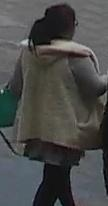

In [31]:
import random
test_dataset = dataset_dict['test']
attr_name = 'Backpack'
attr_dataset = test_dataset.filter(lambda x: x[attr_name] == 0)

random_index = random.randint(0, len(attr_dataset))
image = attr_dataset[random_index]['image']
interpret_result(image, table_label_info, 'rap2')

In [214]:
BATCH_SIZE = 1024
import tqdm
def get_batch_tfresult(list_pil_image):
    assert model.training == False
    images = torch.stack([transform(img) for img in list_pil_image])
    with torch.no_grad():
        result = model.forward_default_test(
            input_var=EasyDict({
                "image": images.cuda(),
                "label": torch.Tensor([[0] * 168] * len(list_pil_image)).cuda(), # pseudo label for not causing error
            }),
            current_step=None,
        )
    cosine_logits = result['pred']['logit'] # use as probs
    probs = torch.nn.functional.sigmoid(cosine_logits)
    # tf_matrix = probs > threshold
    return probs.cpu().numpy()

list_result = []
for i in tqdm.tqdm(range(0, len(test_dataset), BATCH_SIZE)):
    list_pil_image = test_dataset[i:i+BATCH_SIZE]['image']
    list_result.extend(get_batch_tfresult(list_pil_image))

100%|████████████████████████████████████████████████████| 10/10 [00:47<00:00,  4.73s/it]


In [232]:
# table_label_info dump to table_label_info.txt
# %pip install prettytable
import prettytable

prettytable_info = prettytable.PrettyTable()
prettytable_info.field_names = table_label_info.columns
for index, row in table_label_info.iterrows():
    prettytable_info.add_row(row)
    
with open('table_label_info.txt', 'w') as f:
    f.write(str(prettytable_info))



In [201]:
table_label_info[table_label_info['dataset_name'] == 'PA_100k']

,dataset_name,local_label_id,global_label_id,positive_meaning,negative_meaning
54,PA_100k,0,54,with a hat,without a hat
55,PA_100k,1,55,with glasses,without glasses
56,PA_100k,2,56,with short sleeves,without short sleeves
57,PA_100k,3,57,with long sleeves,without long sleeves
58,PA_100k,4,58,with stripe upper-clothes,without stripe upper-clothes
59,PA_100k,5,59,with logo upper-clothes,without logo upper-clothes
60,PA_100k,6,60,with plaid upper-clothes,without plaid upper-clothes
61,PA_100k,7,61,with splice upper-clothes,without splice upper-clothes
62,PA_100k,8,62,with stripe lower-clothes,without stripe lower-clothes
63,PA_100k,9,63,with pattern lower-clothes,without pattern lower-clothes


In [217]:
print(list(dataset_dict['test'].features.keys())[3:])

['Female', 'AgeOver60', 'Age18-60', 'AgeLess18', 'Front', 'Side', 'Back', 'Hat', 'Glasses', 'HandBag', 'ShoulderBag', 'Backpack', 'HoldObjectsInFront', 'ShortSleeve', 'LongSleeve', 'UpperStride', 'UpperLogo', 'UpperPlaid', 'UpperSplice', 'LowerStripe', 'LowerPattern', 'LongCoat', 'Trousers', 'Shorts', 'Skirt&Dress', 'boots']


In [228]:
import numpy as np
import sklearn.metrics

def get_report(list_result, attr_name_in_test_dataset, hulk_index_of_class, threshold=0.5):
    np_result = np.array(list_result) # 10000, 168
    pred_result = np_result[:, hulk_index_of_class] > threshold
    ground_true_hat = np.array([x[attr_name_in_test_dataset] for x in test_dataset])
    res = sklearn.metrics.classification_report(ground_true_hat, pred_result, output_dict=True)
    table_res = pd.DataFrame(res).transpose()
    display(table_res)
    
get_report(list_result, 'LongSleeve', 57, 0.5)

,precision,recall,f1-score,support
0,0.920536,0.904243,0.912317,4407.0000
1,0.925586,0.938495,0.931996,5593.0000
accuracy,0.923400,0.923400,0.923400,0.9234
macro avg,0.923061,0.921369,0.922156,10000.0000
weighted avg,0.923361,0.923400,0.923323,10000.0000


In [241]:
# %pip install diffusers
import requests
from PIL import Image
from io import BytesIO
from diffusers import StableDiffusionUpscalePipeline
import torch

# load model and scheduler
model_id = "stabilityai/stable-diffusion-x4-upscaler"
pipeline = StableDiffusionUpscalePipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipeline = pipeline.to("cuda")

# # let's download an  image
# url = "https://huggingface.co/datasets/hf-internal-testing/diffusers-images/resolve/main/sd2-upscale/low_res_cat.png"
# response = requests.get(url)
# low_res_img = Image.open(BytesIO(response.content)).convert("RGB")
# low_res_img = low_res_img.resize((128, 128))

# get from test_dataset



Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

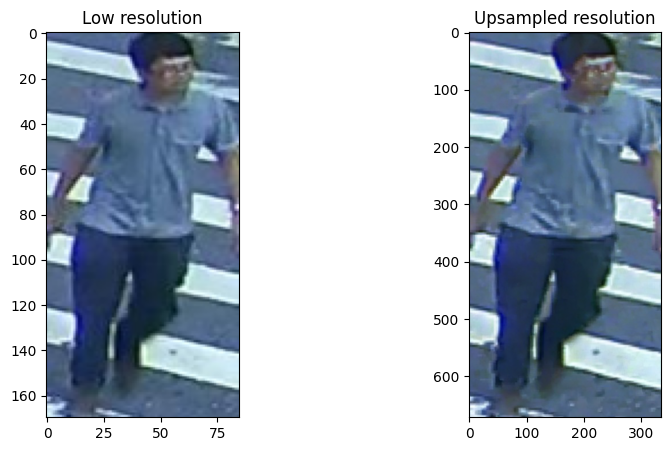

In [270]:
import random
# index = random.randint(0, len(test_dataset))
low_res_img = test_dataset[index]['image'].convert("RGB").resize((int(128//1.5), int(256//1.5)))

# save low_res_img
low_res_img.save("low_resolition.png")
prompt = "A very very sharpness and high resolution photo of a person"
# prompt=None

# step to upscale image: 100
upscaled_image = pipeline(prompt=prompt, image=low_res_img,
                          ).images[0]
# upscaled_image = pipeline(image=low_res_img).images[0]
upscaled_image.save("upsampled_resolution.png")

# plt show two image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(low_res_img)
ax[0].set_title("Low resolution")
ax[1].imshow(upscaled_image)
ax[1].set_title("Upsampled resolution")
plt.show()

#  tính từ "sắc cạnh" trong tiếng anh là "sharpness"

In [16]:
model??

Signature:       model(*args, **kwargs)
Type:            aio_entry_v2mae_shareneck
String form:    
aio_entry_v2mae_shareneck(
  (backbone_module): maskViT(
    (blocks): ModuleList(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
      (1): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, 

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the neural network class
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # Initialize weights for the three nodes
        self.W1 = nn.Parameter(torch.tensor([0.2, 0.7]))
        self.W2 = nn.Parameter(torch.tensor([0.8, 0.4]))
        self.W3 = nn.Parameter(torch.tensor([0.3, 0.3]))

    def forward(self, x):
        # Compute logits
        logits = torch.stack([
            torch.dot(x, self.W1),
            torch.dot(x, self.W2),
            torch.dot(x, self.W3)
        ])
        # Apply softmax to get probability distribution
        probs = F.softmax(logits, dim=0)
        return probs

# Create input data and labels
X1 = torch.tensor([2.0, 1.0])
X2 = torch.tensor([7.0, 4.0])
y1 = torch.tensor(1)  # Class 2
y2 = torch.tensor(1)  # Class 2

# Initialize the model
model = SimpleNN()

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Forward pass for X1
output1 = model(X1.unsqueeze(0))
loss1 = criterion(output1.unsqueeze(0), y1.unsqueeze(0))

# Forward pass for X2
output2 = model(X2.unsqueeze(0))
loss2 = criterion(output2.unsqueeze(0), y2.unsqueeze(0))

# Print the outputs and losses
print(f"Output for X1: {output1}")
print(f"Loss for X1: {loss1.item()}")
print(f"Output for X2: {output2}")
print(f"Loss for X2: {loss2.item()}")

RuntimeError: 1D tensors expected, but got 2D and 1D tensors

In [27]:
W = [[
    [0.2, 0.7],
    [0.8, 0.4],
    [0.3, 0.3]
]]
W = torch.Tensor(W)
X = [[2.0, 1.0], [7.0, 4.0]]
X = torch.Tensor(X)

one_hot = torch.nn.functional.one_hot(torch.tensor([2, 2]), num_classes=3)

logits = torch.matmul(W, X.T).squeeze(0)
softmax = torch.nn.functional.softmax(logits, dim=0)
loss_calculator = nn.CrossEntropyLoss()

loss = loss_calculator(logits.T, torch.tensor([1, 1]))

In [31]:
accuracy = torch.sum(torch.argmax(softmax, dim=0) == torch.tensor([1, 1])) / 2

In [36]:
logits

tensor([[1.1000, 4.2000],
        [2.0000, 7.2000],
        [0.9000, 3.3000]])

In [30]:
softmax.T

tensor([[0.2337, 0.5749, 0.1914],
        [0.0465, 0.9346, 0.0189]])